In [1]:
# data tools and plotting
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Model from scikit-learn
#from sklearn.linear_model import LogisticRegression
#from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)

#### year 12~25

In [3]:
parquet_filename ='../data/processed/tac_co2_processed_v1.parquet'

In [4]:
def best_threshold(X_test, model, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

    f1_scores = 2 * (precisions *recalls) / (precisions + recalls+ 1e-7) # 1e-7 to prevent Nan

    best_idx = np.argmax(f1_scores[:-1])
    best_thres = thresholds[best_idx]

    print(f"Best threshold: {best_thres}")
    print(f"Best F1-score: {f1_scores[best_idx]:.4f}")
    print(f'Precision"{precisions[best_idx]:.4f}", Recall:{recalls[best_idx]}')
   
def plot_importance(model, feature_names, title_suffix=""):
    """
    plotting Feature importance, and upload to MLflow automatically
    """
    print
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values()

    fig, ax = plt.subplots(figsize=(10, 15))
    importances.plot(kind='barh', ax=ax)

    title = f'Feature Importance ({title_suffix})' if title_suffix else "Feature Importance"
    ax.set_title(title)
    fig.tight_layout()

    plt.show()
    plt.close(fig)


def random_forest_model(X_train, y_train, X_test, y_test, feature_names, 
                        experiment_run_name='RF_Model',n_estimators=200, 
                        max_depth=12, n_jobs=-1, threshold=0.5, class_weight=None):
    """
    Fits and evaluate ML models.
    models: dictionary of different ML models
    X_train: training data (no labels)
    X_test: testinh data (no labels)
    y_train: training labels
    y_test: testing labels
    returns model scores dictionary
    """

    model = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth = max_depth,
    random_state=42,
    n_jobs = n_jobs,
    class_weight=class_weight)


    model.fit(X_train, y_train)

    # evaluation and recording Metrics
    y_proba = model.predict_proba(X_test)[:, 1]
    #y_pred = model.predict(X_test)
    y_pred = (y_proba > threshold).astype(int) # threshold should be 0.05 or something
    
    acc = accuracy_score(y_test, y_pred)

    print("Model training completed!")
    print(classification_report(y_test, y_pred))

    cm =confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax =plt.subplots(figsize=(6,6))
    disp.plot(ax=ax,cmap=plt.cm.Blues)
    plt.title(f'Normalized Confusion Matrix, threshold:{threshold}')
    # upload figure to mlflow
    plot_path = f'image/0626_confusion_matrix_{threshold}.png' # to produce the real confusion matrix plot to cover the mlflow autolog's(threshold=0.5 default) 
    plt.savefig(plot_path)
    plt.close()
    print(model.feature_importances_)
    return model
    #plot_importance(model, feature_names, title_suffix=experiment_run_name)

In [5]:
def fill_Nan(df, feature_col):
    df = df.copy()
    for i in feature_col:
        df[i] = df[i].ffill()
    return df

In [6]:
feature_cols =[ 'port',
         'co2_dry','co2_wet', 
         #'co2_target_error', 
         #'co2_Cdrift', 'co2_C', 'co2_N','co2_Nfiltered', 
       'cycle_time', 'h2o', 'cavity_press', 'cavity_temp',
       'das_temp', 'etalon_temp', 'warmbox_temp', 'outlet_valve', 
       #'label1'
]

In [7]:
def get_data_by_year(file_path, year_list):
    df = pd.read_parquet(file_path, filters=[('year', 'in', year_list)])
    return df

train_years = list(range(2012, 2017))
test_years = [2017]

data_train = get_data_by_year(parquet_filename, train_years)
data_test = get_data_by_year(parquet_filename, test_years)


In [8]:
data_train['warmbox_temp'] = data_train['warmbox_temp'].fillna(45)
data_test['warmbox_temp'] = data_train['warmbox_temp'].fillna(45)

X_train = data_train[feature_cols]
y_train = data_train['label1']


X_test = data_test[feature_cols]
y_test = data_test['label1']
#-----------

X_train_filled = fill_Nan(X_train, feature_cols)
X_test_filled = fill_Nan(X_test, feature_cols)

In [9]:
# scaler
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled = scaler.transform(X_test_filled)

In [10]:
X_train_scaled.shape, X_test.shape, y_train.shape, y_test.shape

((2519089, 11), (468913, 11), (2519089,), (468913,))

In [11]:
X_train_filled.isna().sum()

port            0
co2_dry         0
co2_wet         0
cycle_time      0
h2o             0
cavity_press    0
cavity_temp     0
das_temp        0
etalon_temp     0
warmbox_temp    0
outlet_valve    0
dtype: int64

#####　RF MODEL

In [12]:

rf_model = random_forest_model(
        X_train_scaled , y_train, X_test_scaled,  y_test,
        feature_names=feature_cols,
        experiment_run_name=f'rf_first_test', n_estimators=200, max_depth=12, n_jobs=-1,
        threshold=0.5,class_weight=None
    )
best_threshold(X_test_scaled, rf_model, y_test)

Model training completed!
              precision    recall  f1-score   support

         0.0       0.89      0.95      0.92    398960
         1.0       0.54      0.31      0.40     69953

    accuracy                           0.86    468913
   macro avg       0.71      0.63      0.66    468913
weighted avg       0.84      0.86      0.84    468913

[0.35289284 0.0211693  0.02059921 0.08184432 0.04197725 0.09322002
 0.00596194 0.01197855 0.31714002 0.00105147 0.05216509]
Best threshold: 0.5269849507723332
Best F1-score: 0.3990
Precision"0.5908", Recall:0.3012451217245865


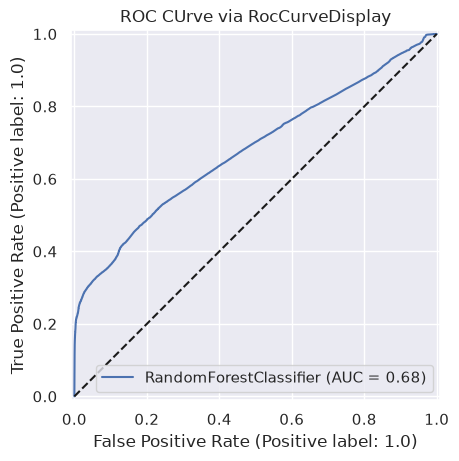

In [13]:
RocCurveDisplay.from_estimator(rf_model, X_test_scaled, y_test)

plt.title('ROC CUrve via RocCurveDisplay')
plt.plot([0, 1], [0,1], 'k--')
plt.show()

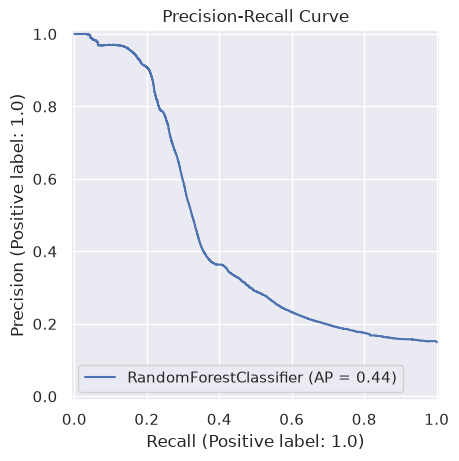

In [14]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(rf_model, X_test_scaled, y_test)

plt.title('Precision-Recall Curve')
plt.show()

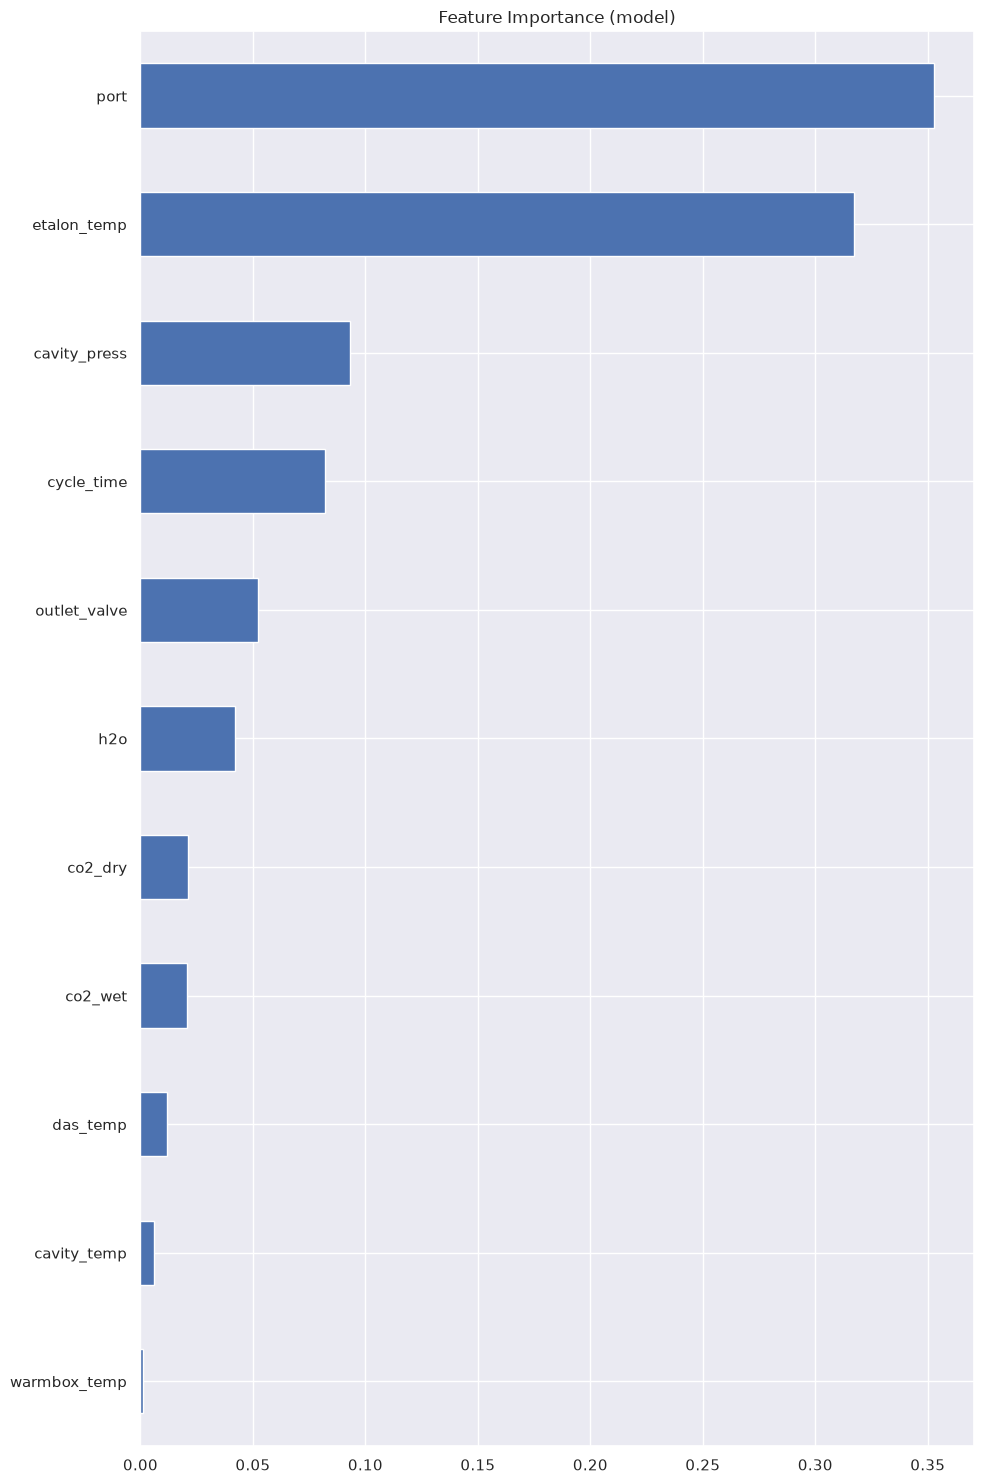

In [17]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values()

fig, ax = plt.subplots(figsize=(10, 15))
importances.plot(kind='barh', ax=ax)

title = f'Feature Importance (model)'
ax.set_title(title)
fig.tight_layout()

plt.show()
plt.close(fig)

In [18]:
import joblib
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('scaler', scaler),
    ('rf', rf_model)
])

pipeline.fit(X_train_scaled, y_train)

joblib.dump(pipeline, 'model/0701_rf_v1_12_16.joblib')

['model/0701_rf_v1_12_16.joblib']

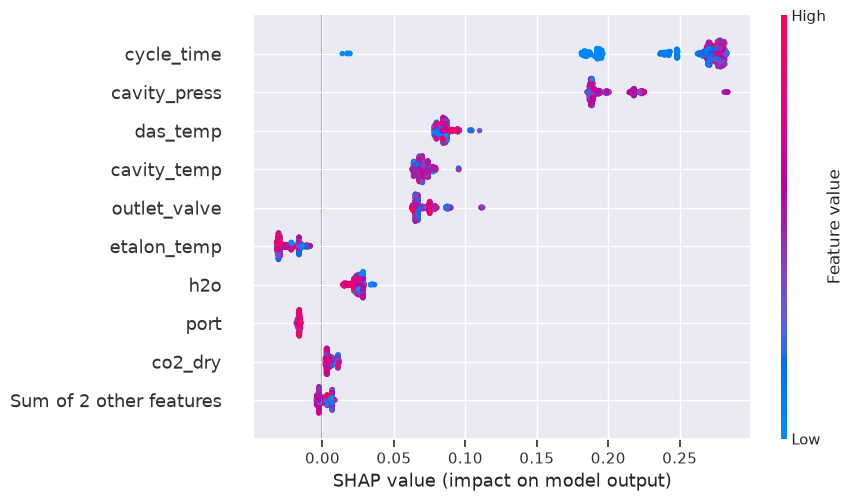

In [21]:
import shap

y_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

threshold =  0.5269849507723332

X_anomalies = X_test[y_probs >= threshold]

#shap
X_sample = shap.utils.sample(X_anomalies, min(len(X_anomalies), 500), random_state=42)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_sample)
shap.plots.beeswarm(shap_values[:, :, 1])

-------